# app

Final Neural Stage Classification

Финальный эксперимент по нейросетевой классификации стадий индукционной пайки.

Основная цель — улучшить качество определения стадии `active_brazing`, сохранив высокое качество распознавания остальных стадий.

## bootstrap

In [1]:
import os
from pathlib import Path

def is_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False
    

IN_COLAB = is_colab()

if IN_COLAB:
    REPO_ROOT = Path("/content") / "BrazingSense"
else:
    REPO_ROOT = Path.cwd().resolve()

if not (REPO_ROOT / ".git").exists():
    raise RuntimeError(f"REPO_ROOT не похож на корень репозитория: {REPO_ROOT}")

os.chdir(REPO_ROOT)

## packages

In [2]:
from pathlib import Path
import json
import time
import random
import warnings
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision import models

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## env

In [3]:
warnings.filterwarnings("ignore")

### constants

In [7]:
FPS = 10
ROOT = Path()
DRIVE_FOLDER = Path('/content/drive/MyDrive/Colab Notebooks/Diploma')
EXPERIMENT_NAME = f"final_neural_stage_classification_{FPS}"

#### path:data

In [12]:
DATA = ROOT / "data" 

DATA_ANNOTATIONS = DATA / "annotations" 
SPLITS_DIR = DATA_ANNOTATIONS / f"splits_{FPS}"
TRAIN_PATH = SPLITS_DIR / "train.csv"
VAL_PATH = SPLITS_DIR / "val.csv"
TEST_PATH = SPLITS_DIR / "test.csv"

DATA_PROCESSED = DATA / 'processed'
DATA_PROCESSED_FRAMES = DATA_PROCESSED / f'frames_{FPS}'

DRIVE_PROCESSED_FRAMES_FOLDER = DRIVE_FOLDER / DATA_PROCESSED_FRAMES

In [13]:
assert TRAIN_PATH.exists(), TRAIN_PATH
assert VAL_PATH.exists(), VAL_PATH
assert TEST_PATH.exists(), TEST_PATH

#### path:reports

In [14]:
REPORTS = ROOT / "reports" 
REPORTS_DIR = REPORTS / EXPERIMENT_NAME
FIGURES_DIR = REPORTS / "figures" / EXPERIMENT_NAME

In [15]:
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

#### path:configs

In [16]:
CONFIG_PATH = ROOT /  "configs"
ROI_CONFIG_PATH = CONFIG_PATH / "roi.yaml"

#### path:model

In [17]:
MODELS_DIR = ROOT / "models"
CHECKPOINTS_DIR = MODELS_DIR / "checkpoints" / EXPERIMENT_NAME

DRIVE_CHECKPOINTS_DIR = DRIVE_FOLDER / CHECKPOINTS_DIR

In [18]:
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

### load

In [19]:
# import subprocess

# if IN_COLAB:
#     from google.colab import drive # type: ignore
#     drive.mount("/content/drive")

#     # cmd = ["cp", "-r", "-v", f"{DRIVE_PROCESSED_FRAMES_FOLDER}/.", f"{DATA_PROCESSED_FRAMES}/"]
#     # with open("copy_frames.log", "w") as log:
#     #     process = subprocess.Popen(cmd, stdout=log, stderr=subprocess.STDOUT, text=True)
#     !cp -r -v "$DRIVE_PROCESSED_FRAMES_FOLDER"/. "$DATA_PROCESSED_FRAMES"/

In [18]:
# print("Process", process.poll())
# !tail copy_frames.log

### seed

In [20]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

### device

In [21]:
torch.backends.cudnn.benchmark = True

In [22]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

### config

In [23]:
STAGE_ORDER = [
    "inactive_preparation",
    "flux_activation",
    "active_brazing",
    "stabilization",
]

STAGE_TO_ID = {
    "inactive_preparation": 0,
    "flux_activation": 1,
    "active_brazing": 2,
    "stabilization": 3,
}

ID_TO_STAGE = {v: k for k, v in STAGE_TO_ID.items()}

ROI = {
    "x": 470,
    "y": 280,
    "w": 430,
    "h": 290,
}

IMAGE_SIZE = 224

# lib

In [24]:
def resolve_path(path_value: str) -> Path:
    path = Path(path_value)
    if path.is_absolute():
        return path
    return ROOT / path

In [25]:
def read_rgb_image(path: Path) -> np.ndarray:
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise ValueError(f"Could not read image: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

In [26]:
def crop_roi(image: np.ndarray, roi: dict) -> np.ndarray:
    x, y, w, h = roi["x"], roi["y"], roi["w"], roi["h"]
    height, width = image.shape[:2]

    x1 = max(0, x)
    y1 = max(0, y)
    x2 = min(width, x + w)
    y2 = min(height, y + h)

    if x1 >= x2 or y1 >= y2:
        raise ValueError(f"Invalid ROI for image shape {image.shape}: {roi}")

    return image[y1:y2, x1:x2]

# model

In [27]:
class BrazingStageDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        roi: dict,
        transform=None,
        project_root: Path | None = None,
    ):
        self.df = df.reset_index(drop=True).copy()
        self.roi = roi
        self.transform = transform
        self.project_root = project_root or Path(".").resolve()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]

        image_path = resolve_path(row["frame_path"])
        image = read_rgb_image(image_path)
        image = crop_roi(image, self.roi)

        if self.transform is not None:
            image = self.transform(image)

        label = int(row["stage_id"])

        metadata = {
            "video_id": row["video_id"],
            "frame_path": row["frame_path"],
            "timestamp_s": float(row["timestamp_s"]),
            "stage_name": row["stage_name"],
        }

        return image, label, metadata

# runtime

## data

In [28]:
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

train_df.head()

train: (5755, 8)
val: (1091, 8)
test: (1732, 8)


,video_id,video_path,frame_path,timestamp_s,stage_id,stage_name,source_fps,target_fps
0,MVI_6268,data/raw/MVI_6268.MOV,data/processed/frames_10/MVI_6268/MVI_6268_000...,0.0,0,inactive_preparation,29.97003,10.0
1,MVI_6268,data/raw/MVI_6268.MOV,data/processed/frames_10/MVI_6268/MVI_6268_000...,0.1,0,inactive_preparation,29.97003,10.0
2,MVI_6268,data/raw/MVI_6268.MOV,data/processed/frames_10/MVI_6268/MVI_6268_000...,0.2,0,inactive_preparation,29.97003,10.0
3,MVI_6268,data/raw/MVI_6268.MOV,data/processed/frames_10/MVI_6268/MVI_6268_000...,0.3,0,inactive_preparation,29.97003,10.0
4,MVI_6268,data/raw/MVI_6268.MOV,data/processed/frames_10/MVI_6268/MVI_6268_000...,0.4,0,inactive_preparation,29.97003,10.0


### check split distribution

In [29]:
def stage_counts(df):
    return df.groupby("stage_name").size().reindex(STAGE_ORDER).fillna(0).astype(int)

split_counts = pd.DataFrame({
    "train": stage_counts(train_df),
    "val": stage_counts(val_df),
    "test": stage_counts(test_df),
})

split_counts

,train,val,test
stage_name,,,
inactive_preparation,3552,734,1000
flux_activation,506,102,138
active_brazing,766,138,196
stabilization,931,117,398


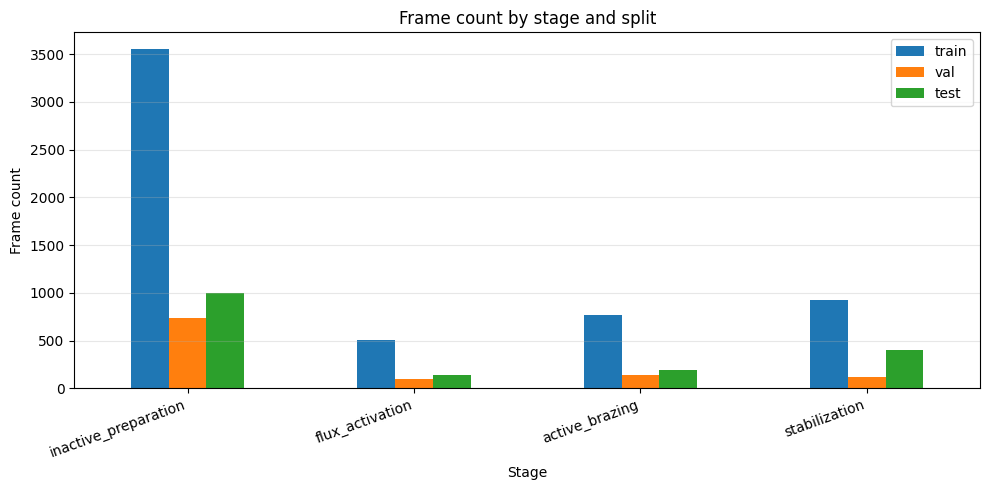

In [30]:
split_counts.plot(kind="bar", figsize=(10, 5))
plt.title("Frame count by stage and split")
plt.xlabel("Stage")
plt.ylabel("Frame count")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### transforms

In [31]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.10,
            hue=0.03,
        )
    ], p=0.7),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))
    ], p=0.2),
    transforms.RandomRotation(degrees=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

### DataLoaders

In [32]:
BATCH_SIZE = 32
NUM_WORKERS = 2

train_dataset = BrazingStageDataset(
    train_df,
    roi=ROI,
    transform=train_transform,
    project_root=ROOT,
)

val_dataset = BrazingStageDataset(
    val_df,
    roi=ROI,
    transform=eval_transform,
    project_root=ROOT,
)

test_dataset = BrazingStageDataset(
    test_df,
    roi=ROI,
    transform=eval_transform,
    project_root=ROOT,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

len(train_dataset), len(val_dataset), len(test_dataset)

(5755, 1091, 1732)

### visual check

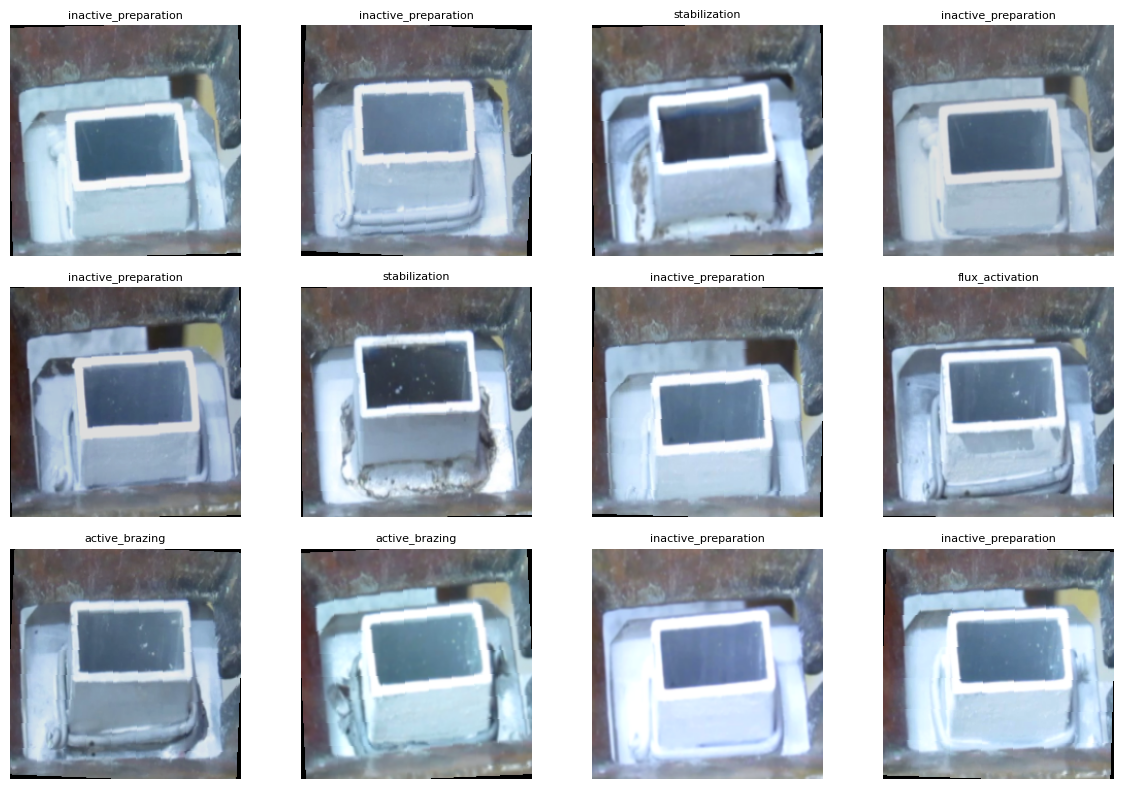

In [33]:
def denormalize_tensor(image_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image = image_tensor.cpu() * std + mean
    image = image.clamp(0, 1)
    return image.permute(1, 2, 0).numpy()


images, labels, metadata = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(min(12, len(images))):
    plt.subplot(3, 4, i + 1)
    plt.imshow(denormalize_tensor(images[i]))
    plt.axis("off")
    plt.title(ID_TO_STAGE[int(labels[i])], fontsize=8)

plt.tight_layout()
plt.show()

## models

### class weights

In [33]:
train_counts = train_df["stage_id"].value_counts().sort_index()
train_counts = train_counts.reindex([0, 1, 2, 3]).fillna(0).astype(int)

total = train_counts.sum()
num_classes = len(train_counts)

class_weights = total / (num_classes * train_counts)
class_weights = torch.tensor(class_weights.values, dtype=torch.float32).to(DEVICE)

train_counts, class_weights

(stage_id
 0    1072
 1     148
 2     229
 3     282
 Name: count, dtype: int64,
 tensor([0.4037, 2.9240, 1.8897, 1.5346], device='cuda:0'))

In [34]:
def make_class_weights(
    train_df: pd.DataFrame,
    mode: str = "balanced",
    active_brazing_boost: float = 1.0,
):
    train_counts = train_df["stage_id"].value_counts().sort_index()
    train_counts = train_counts.reindex([0, 1, 2, 3]).fillna(0).astype(int)

    total = train_counts.sum()
    num_classes = len(train_counts)

    if mode == "none":
        weights = np.ones(num_classes, dtype=np.float32)

    elif mode == "balanced":
        weights = total / (num_classes * train_counts.values)
        weights = weights.astype(np.float32)

    else:
        raise ValueError(f"Unknown class weight mode: {mode}")

    # Усиливаем active_brazing, потому что это главная проблемная стадия.
    weights[2] *= active_brazing_boost

    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


base_class_weights = make_class_weights(
    train_df,
    mode="balanced",
    active_brazing_boost=1.0,
)

active_boost_class_weights = make_class_weights(
    train_df,
    mode="balanced",
    active_brazing_boost=1.5,
)

base_class_weights, active_boost_class_weights

(tensor([0.4051, 2.8434, 1.8783, 1.5454], device='cuda:0'),
 tensor([0.4051, 2.8434, 2.8174, 1.5454], device='cuda:0'))

### factory

In [35]:
def create_model(model_name: str, num_classes: int = 4, pretrained: bool = True):
    model_name = model_name.lower()

    if model_name == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        model = models.resnet18(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        return model

    if model_name == "mobilenet_v3_small":
        weights = models.MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)
        return model

    raise ValueError(f"Unknown model_name: {model_name}")

### eval functions

In [38]:
def run_one_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    device=DEVICE,
):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_targets = []
    all_preds = []

    for images, labels, _ in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)

        all_targets.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")
    weighted_f1 = f1_score(all_targets, all_preds, average="weighted")

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }

### predict func

In [39]:
def predict_loader(model, loader, device=DEVICE):
    model.eval()

    all_logits = []
    all_probs = []
    all_preds = []
    all_targets = []
    all_metadata = []

    with torch.no_grad():
        for images, labels, metadata in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_logits.append(logits.cpu())
            all_probs.append(probs.cpu())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_targets.extend(labels.cpu().numpy().tolist())

            batch_size = len(labels)
            for i in range(batch_size):
                all_metadata.append({
                    "video_id": metadata["video_id"][i],
                    "frame_path": metadata["frame_path"][i],
                    "timestamp_s": float(metadata["timestamp_s"][i]),
                    "stage_name": metadata["stage_name"][i],
                })

    probs_np = torch.cat(all_probs, dim=0).numpy()

    pred_df = pd.DataFrame(all_metadata)
    pred_df["stage_id"] = all_targets
    pred_df["pred_stage_id"] = all_preds
    pred_df["pred_stage_name"] = pred_df["pred_stage_id"].map(ID_TO_STAGE)

    for class_id, stage_name in ID_TO_STAGE.items():
        pred_df[f"prob_{stage_name}"] = probs_np[:, class_id]

    return pred_df

### train functions

In [40]:
def train_model(
    model_name: str,
    run_name: str,
    class_weights_for_run: torch.Tensor,
    epochs: int = 20,
    lr: float = 3e-4,
    weight_decay: float = 1e-4,
):
    model = create_model(model_name, num_classes=4, pretrained=True).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights_for_run)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=4,
    )

    best_val_macro_f1 = -1.0
    best_val_active_brazing_f1 = -1.0
    best_state = None
    history = []

    for epoch in range(1, epochs + 1):
        start_time = time.time()

        train_metrics = run_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
            device=DEVICE,
        )

        val_metrics = run_one_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None,
            device=DEVICE,
        )

        # Дополнительно считаем per-class report на val.
        val_pred_df = predict_loader(model, val_loader)
        y_val_true = val_pred_df["stage_id"].to_numpy()
        y_val_pred = val_pred_df["pred_stage_id"].to_numpy()

        val_report = classification_report(
            y_val_true,
            y_val_pred,
            labels=[0, 1, 2, 3],
            target_names=STAGE_ORDER,
            output_dict=True,
            zero_division=0,
        )

        val_active_brazing_f1 = val_report["active_brazing"]["f1-score"]
        val_active_brazing_recall = val_report["active_brazing"]["recall"]

        scheduler.step(val_metrics["macro_f1"])

        epoch_time = time.time() - start_time

        row = {
            "epoch": epoch,
            "run_name": run_name,
            "model_name": model_name,
            "lr": optimizer.param_groups[0]["lr"],
            "epoch_time_s": epoch_time,
            "val_active_brazing_f1": val_active_brazing_f1,
            "val_active_brazing_recall": val_active_brazing_recall,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }

        history.append(row)

        print(
            f"[{run_name}] "
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_f1={train_metrics['macro_f1']:.4f} | "
            f"val_f1={val_metrics['macro_f1']:.4f} "
            f"val_acc={val_metrics['accuracy']:.4f} "
            f"val_active_f1={val_active_brazing_f1:.4f} "
            f"val_active_recall={val_active_brazing_recall:.4f} | "
            f"{epoch_time:.1f}s"
        )

        # Основной критерий пока macro-F1.
        # Но сохраняем также active_brazing показатели в checkpoint.
        if val_metrics["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["macro_f1"]
            best_val_active_brazing_f1 = val_active_brazing_f1

            best_state = {
                "run_name": run_name,
                "model_name": model_name,
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "val_macro_f1": best_val_macro_f1,
                "val_active_brazing_f1": best_val_active_brazing_f1,
                "roi": ROI,
                "image_size": IMAGE_SIZE,
                "stage_order": STAGE_ORDER,
                "fps": FPS,
            }

    history_df = pd.DataFrame(history)

    checkpoint_path = CHECKPOINTS_DIR / f"{run_name}_best_{FPS}fps.pt"
    torch.save(best_state, checkpoint_path)

    history_path = REPORTS_DIR / f"{run_name}_history_{FPS}fps.csv"
    history_df.to_csv(history_path, index=False)

    print(f"Best val macro-F1 for {run_name}: {best_val_macro_f1:.4f}")
    print(f"Saved checkpoint: {checkpoint_path}")

    model.load_state_dict(best_state["model_state_dict"])

    return model, history_df, checkpoint_path

In [41]:
# def train_model(
#     model_name: str,
#     epochs: int = 25,
#     lr: float = 3e-4,
#     weight_decay: float = 1e-4,
# ):
#     model = create_model(model_name, num_classes=4, pretrained=True).to(DEVICE)

#     criterion = nn.CrossEntropyLoss(weight=class_weights)
#     optimizer = torch.optim.AdamW(
#         model.parameters(),
#         lr=lr,
#         weight_decay=weight_decay,
#     )

#     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#         optimizer,
#         mode="max",
#         factor=0.5,
#         patience=4,
#     )

#     best_val_macro_f1 = -1.0
#     best_state = None
#     history = []

#     for epoch in range(1, epochs + 1):
#         start_time = time.time()

#         train_metrics = run_one_epoch(
#             model,
#             train_loader,
#             criterion,
#             optimizer=optimizer,
#             device=DEVICE,
#         )

#         val_metrics = run_one_epoch(
#             model,
#             val_loader,
#             criterion,
#             optimizer=None,
#             device=DEVICE,
#         )

#         scheduler.step(val_metrics["macro_f1"])

#         epoch_time = time.time() - start_time

#         row = {
#             "epoch": epoch,
#             "model_name": model_name,
#             "lr": optimizer.param_groups[0]["lr"],
#             "epoch_time_s": epoch_time,
#             **{f"train_{k}": v for k, v in train_metrics.items()},
#             **{f"val_{k}": v for k, v in val_metrics.items()},
#         }

#         history.append(row)

#         print(
#             f"[{model_name}] "
#             f"Epoch {epoch:02d}/{epochs} | "
#             f"train_loss={train_metrics['loss']:.4f} "
#             f"train_f1={train_metrics['macro_f1']:.4f} | "
#             f"val_loss={val_metrics['loss']:.4f} "
#             f"val_f1={val_metrics['macro_f1']:.4f} "
#             f"val_acc={val_metrics['accuracy']:.4f} | "
#             f"{epoch_time:.1f}s"
#         )

#         if val_metrics["macro_f1"] > best_val_macro_f1:
#             best_val_macro_f1 = val_metrics["macro_f1"]
#             best_state = {
#                 "model_name": model_name,
#                 "model_state_dict": model.state_dict(),
#                 "epoch": epoch,
#                 "val_macro_f1": best_val_macro_f1,
#                 "roi": ROI,
#                 "image_size": IMAGE_SIZE,
#                 "stage_order": STAGE_ORDER,
#             }

#     history_df = pd.DataFrame(history)

#     checkpoint_path = CHECKPOINTS_DIR / f"{model_name}_best_{FPS}.pt"
#     torch.save(best_state, checkpoint_path)

#     history_path = REPORTS_DIR / f"{model_name}_history_{FPS}.csv"
#     history_df.to_csv(history_path, index=False)

#     print(f"Best val macro-F1 for {model_name}: {best_val_macro_f1:.4f}")
#     print(f"Saved checkpoint: {checkpoint_path}")

#     model.load_state_dict(best_state["model_state_dict"])

#     return model, history_df, checkpoint_path

### resnet18

In [42]:
resnet18_10fps_model, resnet18_10fps_history, resnet18_10fps_checkpoint = train_model(
    model_name="resnet18",
    run_name="resnet18_10fps_balanced",
    class_weights_for_run=base_class_weights,
    epochs=20,
    lr=3e-4,
    weight_decay=1e-4,
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s] 


[resnet18_10fps_balanced] Epoch 01/20 | train_f1=0.8655 | val_f1=0.5471 val_acc=0.8176 val_active_f1=0.6053 val_active_recall=1.0000 | 58.2s
[resnet18_10fps_balanced] Epoch 02/20 | train_f1=0.9426 | val_f1=0.8270 val_acc=0.8708 val_active_f1=0.8617 val_active_recall=0.7899 | 57.5s
[resnet18_10fps_balanced] Epoch 03/20 | train_f1=0.9556 | val_f1=0.6727 val_acc=0.7690 val_active_f1=0.5375 val_active_recall=0.9855 | 57.5s
[resnet18_10fps_balanced] Epoch 04/20 | train_f1=0.9659 | val_f1=0.7226 val_acc=0.8653 val_active_f1=0.6890 val_active_recall=0.8188 | 57.0s
[resnet18_10fps_balanced] Epoch 05/20 | train_f1=0.9704 | val_f1=0.8265 val_acc=0.9212 val_active_f1=0.8098 val_active_recall=0.9565 | 57.3s
[resnet18_10fps_balanced] Epoch 06/20 | train_f1=0.9747 | val_f1=0.6495 val_acc=0.8258 val_active_f1=0.6356 val_active_recall=0.8406 | 57.5s
[resnet18_10fps_balanced] Epoch 07/20 | train_f1=0.9788 | val_f1=0.8270 val_acc=0.8909 val_active_f1=0.7542 val_active_recall=0.6449 | 57.7s
[resnet18_10f

In [43]:
resnet18_boost_model, resnet18_boost_history, resnet18_boost_checkpoint = train_model(
    model_name="resnet18",
    run_name="resnet18_10fps_active_brazing_boost_1_5",
    class_weights_for_run=active_boost_class_weights,
    epochs=20,
    lr=3e-4,
    weight_decay=1e-4,
)

[resnet18_10fps_active_brazing_boost_1_5] Epoch 01/20 | train_f1=0.8663 | val_f1=0.7259 val_acc=0.8368 val_active_f1=0.6168 val_active_recall=0.7464 | 57.1s
[resnet18_10fps_active_brazing_boost_1_5] Epoch 02/20 | train_f1=0.9442 | val_f1=0.7883 val_acc=0.9038 val_active_f1=0.7500 val_active_recall=0.9565 | 57.5s
[resnet18_10fps_active_brazing_boost_1_5] Epoch 03/20 | train_f1=0.9621 | val_f1=0.8339 val_acc=0.9230 val_active_f1=0.8401 val_active_recall=0.9710 | 57.5s
[resnet18_10fps_active_brazing_boost_1_5] Epoch 04/20 | train_f1=0.9687 | val_f1=0.8473 val_acc=0.9267 val_active_f1=0.8133 val_active_recall=0.9783 | 57.1s
[resnet18_10fps_active_brazing_boost_1_5] Epoch 05/20 | train_f1=0.9663 | val_f1=0.7762 val_acc=0.8689 val_active_f1=0.7586 val_active_recall=0.9565 | 57.0s
[resnet18_10fps_active_brazing_boost_1_5] Epoch 06/20 | train_f1=0.9725 | val_f1=0.8865 val_acc=0.9432 val_active_f1=0.8034 val_active_recall=0.6812 | 57.5s
[resnet18_10fps_active_brazing_boost_1_5] Epoch 07/20 | tr

### mobilenet_v3_small

In [44]:
mobilenet_10fps_model, mobilenet_10fps_history, mobilenet_10fps_checkpoint = train_model(
    model_name="mobilenet_v3_small",
    run_name="mobilenet_v3_small_10fps_balanced",
    class_weights_for_run=base_class_weights,
    epochs=20,
    lr=3e-4,
    weight_decay=1e-4,
)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 96.8MB/s]


[mobilenet_v3_small_10fps_balanced] Epoch 01/20 | train_f1=0.8317 | val_f1=0.5557 val_acc=0.8121 val_active_f1=0.5461 val_active_recall=0.6014 | 94.5s
[mobilenet_v3_small_10fps_balanced] Epoch 02/20 | train_f1=0.9405 | val_f1=0.6966 val_acc=0.8368 val_active_f1=0.6059 val_active_recall=0.8913 | 57.8s
[mobilenet_v3_small_10fps_balanced] Epoch 03/20 | train_f1=0.9579 | val_f1=0.6288 val_acc=0.6994 val_active_f1=0.4946 val_active_recall=1.0000 | 57.7s
[mobilenet_v3_small_10fps_balanced] Epoch 04/20 | train_f1=0.9666 | val_f1=0.7030 val_acc=0.8579 val_active_f1=0.6006 val_active_recall=0.7029 | 57.5s
[mobilenet_v3_small_10fps_balanced] Epoch 05/20 | train_f1=0.9690 | val_f1=0.6770 val_acc=0.8048 val_active_f1=0.5973 val_active_recall=0.9565 | 57.5s
[mobilenet_v3_small_10fps_balanced] Epoch 06/20 | train_f1=0.9724 | val_f1=0.7755 val_acc=0.8900 val_active_f1=0.7097 val_active_recall=0.8768 | 57.5s
[mobilenet_v3_small_10fps_balanced] Epoch 07/20 | train_f1=0.9733 | val_f1=0.7826 val_acc=0.89

### results

#### training curves

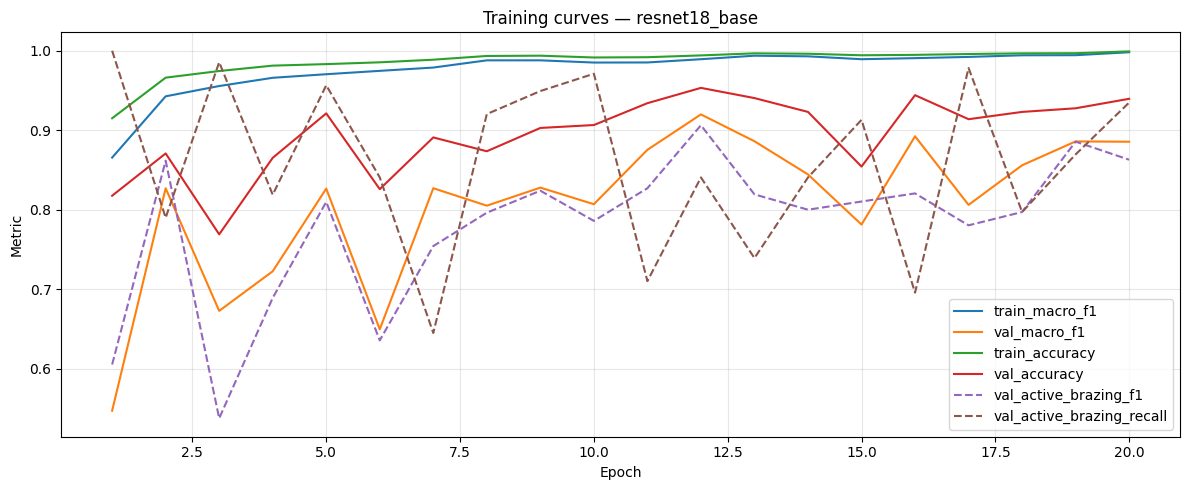

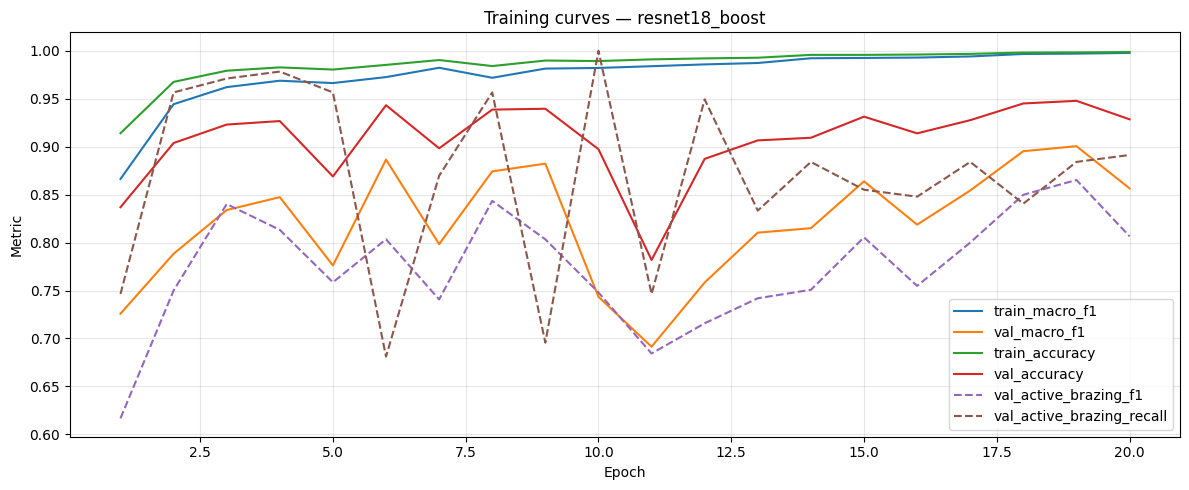

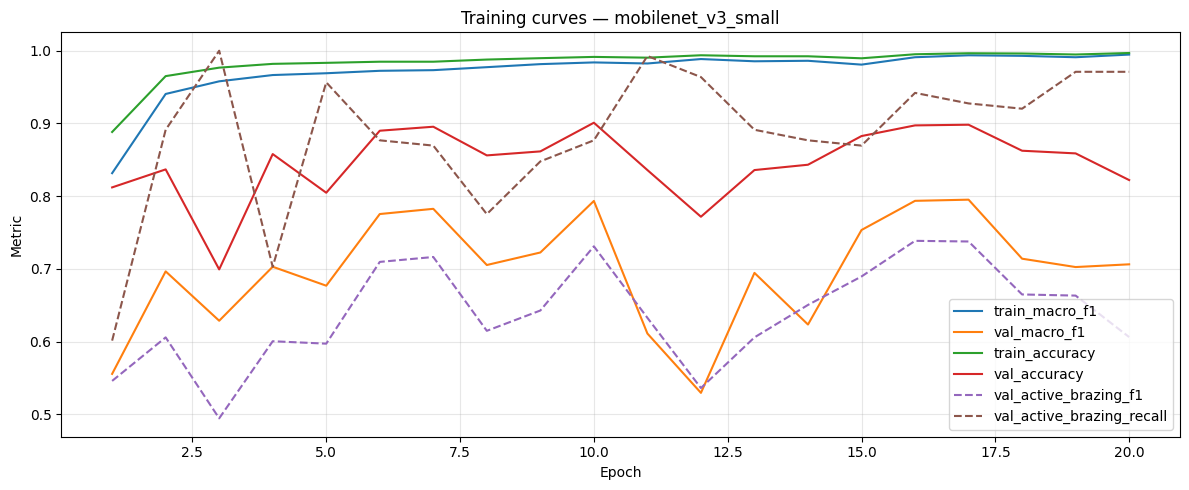

In [45]:
def plot_history(history_df, model_name):
    plt.figure(figsize=(12, 5))

    plt.plot(history_df["epoch"], history_df["train_macro_f1"], label="train_macro_f1")
    plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="val_macro_f1")
    plt.plot(history_df["epoch"], history_df["train_accuracy"], label="train_accuracy")
    plt.plot(history_df["epoch"], history_df["val_accuracy"], label="val_accuracy")
    plt.plot(history_df["epoch"], history_df["val_active_brazing_f1"], label="val_active_brazing_f1", linestyle="--")
    plt.plot(history_df["epoch"], history_df["val_active_brazing_recall"], label="val_active_brazing_recall", linestyle="--")

    plt.title(f"Training curves — {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_path = FIGURES_DIR / f"{model_name}_training_curves_{FPS}.png"
    plt.savefig(output_path, dpi=160)
    plt.show()


plot_history(resnet18_10fps_history, "resnet18_base")
plot_history(resnet18_boost_history, "resnet18_boost")
plot_history(mobilenet_10fps_history, "mobilenet_v3_small")

#### compare validation metrics

In [46]:
def best_epoch_row(history_df: pd.DataFrame) -> pd.Series:
    return history_df.loc[history_df["val_macro_f1"].idxmax()]


model_comparison = pd.DataFrame([
    {
        "model": "resnet18_base",
        "best_val_macro_f1": best_epoch_row(resnet18_10fps_history)["val_macro_f1"],
        "best_val_accuracy": best_epoch_row(resnet18_10fps_history)["val_accuracy"],
        "best_val_active_brazing_f1": best_epoch_row(resnet18_10fps_history).get("val_active_brazing_f1", np.nan),
        "best_val_active_brazing_recall": best_epoch_row(resnet18_10fps_history).get("val_active_brazing_recall", np.nan),
        "checkpoint": str(resnet18_10fps_checkpoint),
    },
    {
        "model": "resnet18_boost",
        "best_val_macro_f1": best_epoch_row(resnet18_boost_history)["val_macro_f1"],
        "best_val_accuracy": best_epoch_row(resnet18_boost_history)["val_accuracy"],
        "best_val_active_brazing_f1": best_epoch_row(resnet18_boost_history).get("val_active_brazing_f1", np.nan),
        "best_val_active_brazing_recall": best_epoch_row(resnet18_boost_history).get("val_active_brazing_recall", np.nan),
        "checkpoint": str(resnet18_boost_checkpoint),
    },
    {
        "model": "mobilenet_v3_small",
        "best_val_macro_f1": best_epoch_row(mobilenet_10fps_history)["val_macro_f1"],
        "best_val_accuracy": best_epoch_row(mobilenet_10fps_history)["val_accuracy"],
        "best_val_active_brazing_f1": best_epoch_row(mobilenet_10fps_history).get("val_active_brazing_f1", np.nan),
        "best_val_active_brazing_recall": best_epoch_row(mobilenet_10fps_history).get("val_active_brazing_recall", np.nan),
        "checkpoint": str(mobilenet_10fps_checkpoint),
    },
])

model_comparison

,model,best_val_macro_f1,best_val_accuracy,best_val_active_brazing_f1,best_val_active_brazing_recall,checkpoint
0,resnet18_base,0.919863,0.953254,0.906250,0.840580,models/checkpoints/final_neural_stage_classifi...
1,resnet18_boost,0.900480,0.947754,0.865248,0.884058,models/checkpoints/final_neural_stage_classifi...
2,mobilenet_v3_small,0.795232,0.898258,0.737752,0.927536,models/checkpoints/final_neural_stage_classifi...


#### select best model

In [47]:
best_row = model_comparison.sort_values("best_val_macro_f1", ascending=False).iloc[0]
best_model_name = best_row["model"]
best_checkpoint_path = Path(best_row["checkpoint"])

best_model_name, best_checkpoint_path

('resnet18_base',
 PosixPath('models/checkpoints/final_neural_stage_classification_10/resnet18_10fps_balanced_best_10fps.pt'))

In [48]:
active_best_row = model_comparison.sort_values(
    ["best_val_active_brazing_f1", "best_val_macro_f1"],
    ascending=False,
).iloc[0]

active_best_model_name = active_best_row["model"]
active_best_checkpoint_path = Path(active_best_row["checkpoint"])

active_best_model_name, active_best_checkpoint_path

('resnet18_base',
 PosixPath('models/checkpoints/final_neural_stage_classification_10/resnet18_10fps_balanced_best_10fps.pt'))

In [49]:
checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)

best_model = create_model(
    checkpoint["model_name"],
    num_classes=4,
    pretrained=False,
).to(DEVICE)

best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

checkpoint["run_name"], checkpoint["model_name"], checkpoint["epoch"], checkpoint["val_macro_f1"], checkpoint.get("val_active_brazing_f1")

('resnet18_10fps_balanced', 'resnet18', 12, 0.919862516239195, 0.90625)

## test

### evaluate function

In [50]:
def evaluate_predictions(pred_df: pd.DataFrame, title: str):
    y_true = pred_df["stage_id"].to_numpy()
    y_pred = pred_df["pred_stage_id"].to_numpy()

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print(title)
    print("-" * 80)
    print(f"accuracy:    {acc:.4f}")
    print(f"macro_f1:    {macro_f1:.4f}")
    print(f"weighted_f1: {weighted_f1:.4f}")
    print()

    print(classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2, 3],
        target_names=STAGE_ORDER,
        digits=4,
        zero_division=0,
    ))

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=STAGE_ORDER,
    )

    fig, ax = plt.subplots(figsize=(8, 7))
    disp.plot(ax=ax, xticks_rotation=30, values_format="d")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "confusion_matrix": cm.tolist(),
    }

### test evaluation

Test — resnet18_base
--------------------------------------------------------------------------------
accuracy:    0.8747
macro_f1:    0.8209
weighted_f1: 0.8895

                      precision    recall  f1-score   support

inactive_preparation     0.9988    0.8480    0.9173      1000
     flux_activation     0.4255    0.9928    0.5957       138
      active_brazing     0.9926    0.6837    0.8097       196
       stabilization     0.9296    0.9950    0.9612       398

            accuracy                         0.8747      1732
           macro avg     0.8366    0.8799    0.8209      1732
        weighted avg     0.9365    0.8747    0.8895      1732



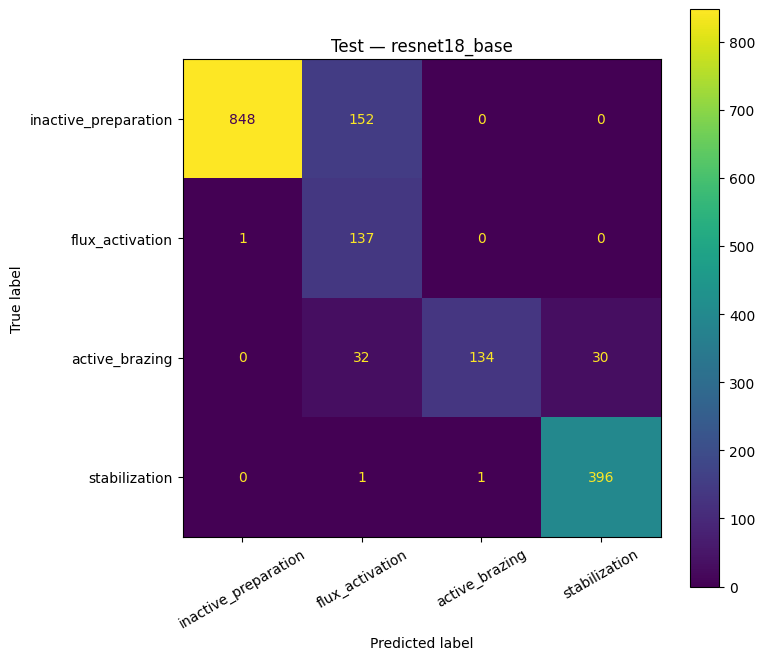

,video_id,frame_path,timestamp_s,stage_name,stage_id,pred_stage_id,pred_stage_name,prob_inactive_preparation,prob_flux_activation,prob_active_brazing,prob_stabilization
0,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.0,inactive_preparation,0,0,inactive_preparation,0.689079,0.167046,0.072961,0.070914
1,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.1,inactive_preparation,0,1,flux_activation,0.318643,0.434341,0.107281,0.139735
2,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.2,inactive_preparation,0,0,inactive_preparation,0.467962,0.320719,0.114499,0.096820
3,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.3,inactive_preparation,0,0,inactive_preparation,0.489105,0.242795,0.184225,0.083875
4,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.4,inactive_preparation,0,0,inactive_preparation,0.779270,0.067154,0.088990,0.064586


In [51]:
test_pred_df = predict_loader(best_model, test_loader)

test_metrics = evaluate_predictions(
    test_pred_df,
    title=f"Test — {best_model_name}",
)

test_pred_df.head()

In [52]:
test_pred_df.to_csv(REPORTS_DIR / f"{best_model_name}_test_predictions_{FPS}.csv", index=False)

with open(REPORTS_DIR / f"{best_model_name}_test_metrics_{FPS}.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "model": best_model_name,
            "checkpoint": str(best_checkpoint_path),
            "test_metrics": test_metrics,
            "stage_order": STAGE_ORDER,
            "roi": ROI,
            "image_size": IMAGE_SIZE,
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

### error pairs

In [53]:
errors_df = test_pred_df[test_pred_df["stage_id"] != test_pred_df["pred_stage_id"]].copy()

error_pairs = (
    errors_df
    .groupby(["stage_name", "pred_stage_name"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

error_pairs

,stage_name,pred_stage_name,count
3,inactive_preparation,flux_activation,152
0,active_brazing,flux_activation,32
1,active_brazing,stabilization,30
2,flux_activation,inactive_preparation,1
4,stabilization,active_brazing,1
5,stabilization,flux_activation,1


### timeline plots

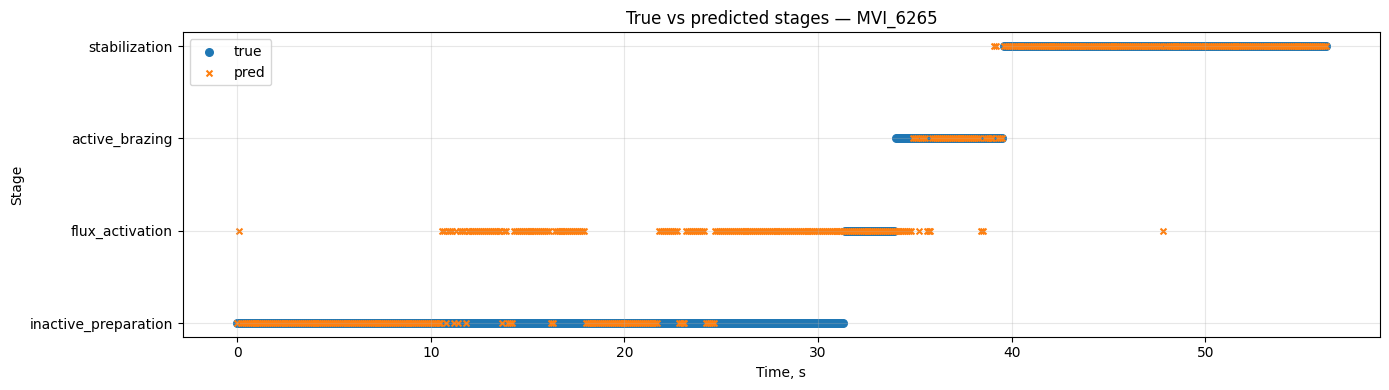

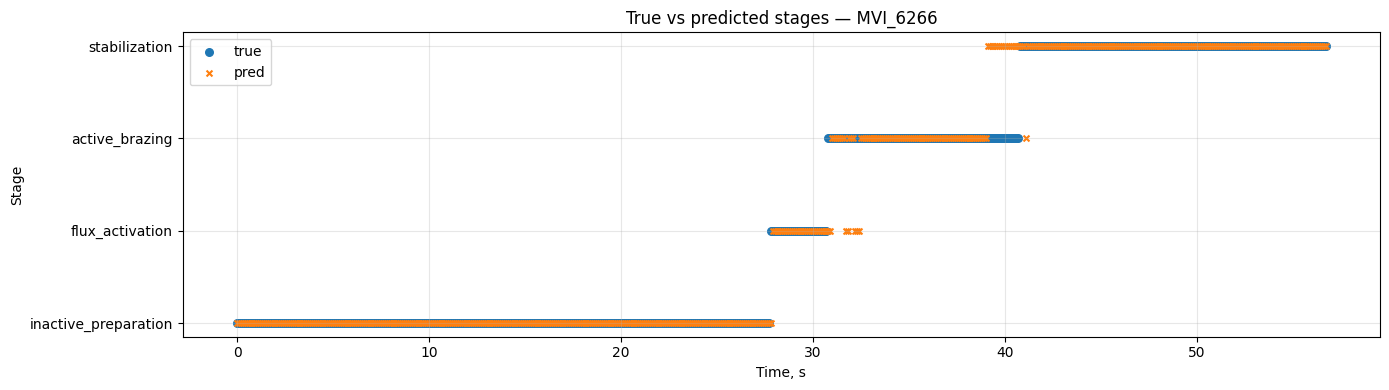

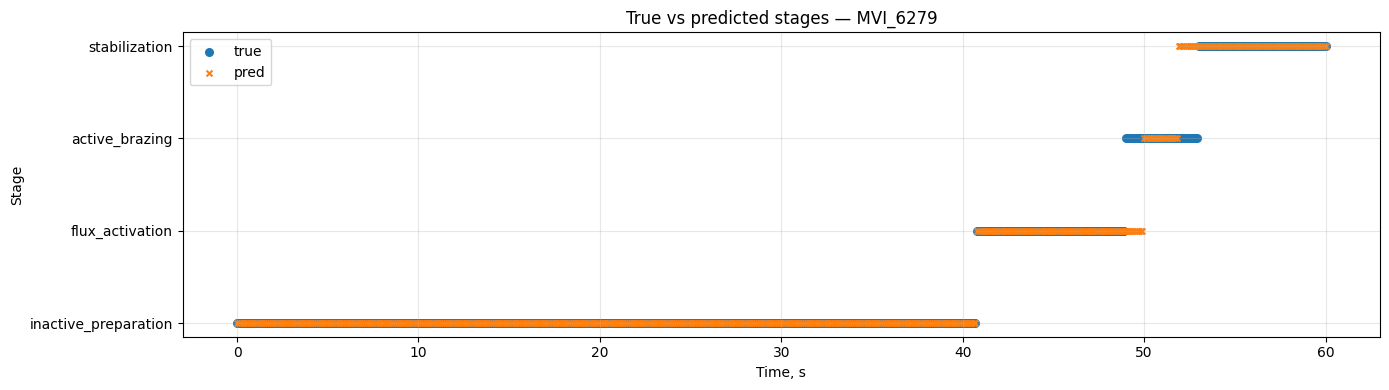

In [54]:
def plot_predictions_for_video(pred_df: pd.DataFrame, video_id: str, output_prefix: str = "raw"):
    video_df = pred_df[pred_df["video_id"] == video_id].sort_values("timestamp_s")

    if len(video_df) == 0:
        print(f"No rows for {video_id}")
        return

    plt.figure(figsize=(14, 4))

    plt.scatter(
        video_df["timestamp_s"],
        video_df["stage_id"],
        s=30,
        label="true",
        marker="o",
    )

    plt.scatter(
        video_df["timestamp_s"],
        video_df["pred_stage_id"],
        s=18,
        label="pred",
        marker="x",
    )

    plt.yticks([0, 1, 2, 3], STAGE_ORDER)
    plt.xlabel("Time, s")
    plt.ylabel("Stage")
    plt.title(f"True vs predicted stages — {video_id}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_path = FIGURES_DIR / f"{video_id}_{output_prefix}_neural_predictions_timeline_{FPS}.png"
    plt.savefig(output_path, dpi=160)
    plt.show()


for video_id in sorted(test_pred_df["video_id"].unique()):
    plot_predictions_for_video(test_pred_df, video_id)

## temporal smoothing

In [55]:
def smooth_stage_predictions(
    video_df: pd.DataFrame,
    pred_col: str = "pred_stage_id",
    output_col: str = "pred_stage_id_smooth",
    window_size: int = 5,
) -> pd.DataFrame:
    video_df = video_df.sort_values("timestamp_s").copy()
    preds = video_df[pred_col].to_numpy()

    half = window_size // 2
    smoothed = []

    for i in range(len(preds)):
        left = max(0, i - half)
        right = min(len(preds), i + half + 1)

        window = preds[left:right]
        most_common_stage = Counter(window).most_common(1)[0][0]
        smoothed.append(most_common_stage)

    video_df[output_col] = smoothed
    video_df["pred_stage_name_smooth"] = video_df[output_col].map(ID_TO_STAGE)

    return video_df


smoothed_parts = []

for video_id, video_df in test_pred_df.groupby("video_id"):
    smoothed_parts.append(
        smooth_stage_predictions(
            video_df,
            pred_col="pred_stage_id",
            output_col="pred_stage_id_smooth",
            window_size=5,
        )
    )

test_smoothed_df = pd.concat(smoothed_parts).sort_values(
    ["video_id", "timestamp_s"]
).reset_index(drop=True)

test_smoothed_df.head()

,video_id,frame_path,timestamp_s,stage_name,stage_id,pred_stage_id,pred_stage_name,prob_inactive_preparation,prob_flux_activation,prob_active_brazing,prob_stabilization,pred_stage_id_smooth,pred_stage_name_smooth
0,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.0,inactive_preparation,0,0,inactive_preparation,0.689079,0.167046,0.072961,0.070914,0,inactive_preparation
1,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.1,inactive_preparation,0,1,flux_activation,0.318643,0.434341,0.107281,0.139735,0,inactive_preparation
2,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.2,inactive_preparation,0,0,inactive_preparation,0.467962,0.320719,0.114499,0.096820,0,inactive_preparation
3,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.3,inactive_preparation,0,0,inactive_preparation,0.489105,0.242795,0.184225,0.083875,0,inactive_preparation
4,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.4,inactive_preparation,0,0,inactive_preparation,0.779270,0.067154,0.088990,0.064586,0,inactive_preparation


### evaluate smoothing

Test — resnet18_base + temporal smoothing
--------------------------------------------------------------------------------
accuracy:    0.8776
macro_f1:    0.8290
weighted_f1: 0.8926

                      precision    recall  f1-score   support

inactive_preparation     0.9988    0.8440    0.9149      1000
     flux_activation     0.4281    0.9928    0.5983       138
      active_brazing     1.0000    0.7194    0.8368       196
       stabilization     0.9343    1.0000    0.9660       398

            accuracy                         0.8776      1732
           macro avg     0.8403    0.8890    0.8290      1732
        weighted avg     0.9386    0.8776    0.8926      1732



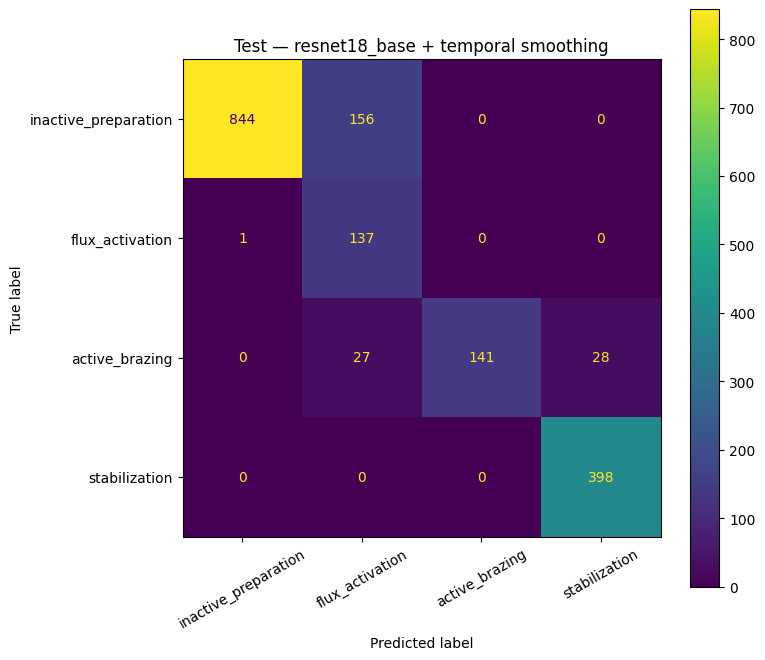

In [56]:
smoothed_eval_df = test_smoothed_df.copy()
smoothed_eval_df["pred_stage_id_raw"] = smoothed_eval_df["pred_stage_id"]
smoothed_eval_df["pred_stage_name_raw"] = smoothed_eval_df["pred_stage_name"]

smoothed_eval_df["pred_stage_id"] = smoothed_eval_df["pred_stage_id_smooth"]
smoothed_eval_df["pred_stage_name"] = smoothed_eval_df["pred_stage_name_smooth"]

smoothed_metrics = evaluate_predictions(
    smoothed_eval_df,
    title=f"Test — {best_model_name} + temporal smoothing",
)

In [57]:
with open(REPORTS_DIR / f"{best_model_name}_test_metrics_smoothed_{FPS}.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "model": best_model_name,
            "checkpoint": str(best_checkpoint_path),
            "window_size": 5,
            "test_metrics": smoothed_metrics,
            "stage_order": STAGE_ORDER,
            "roi": ROI,
            "image_size": IMAGE_SIZE,
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

### timeline plots

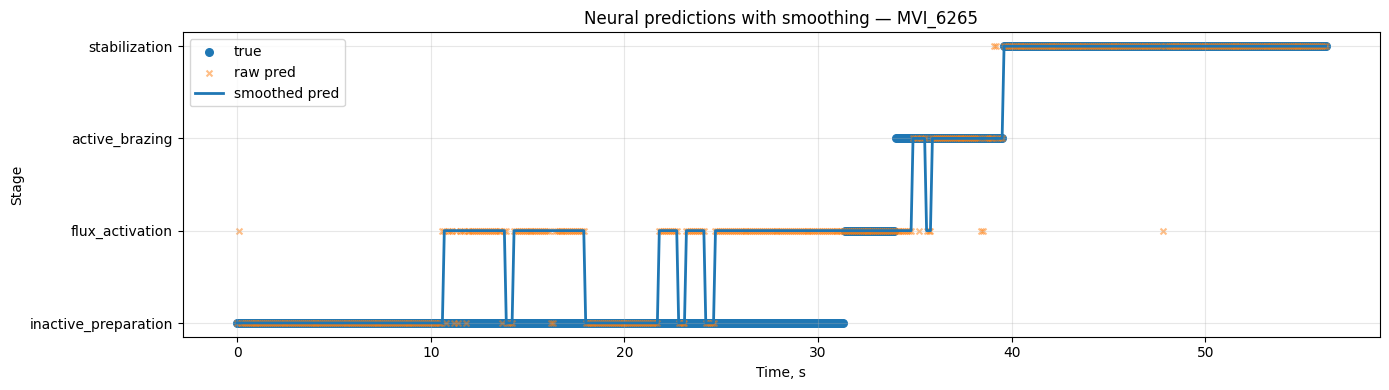

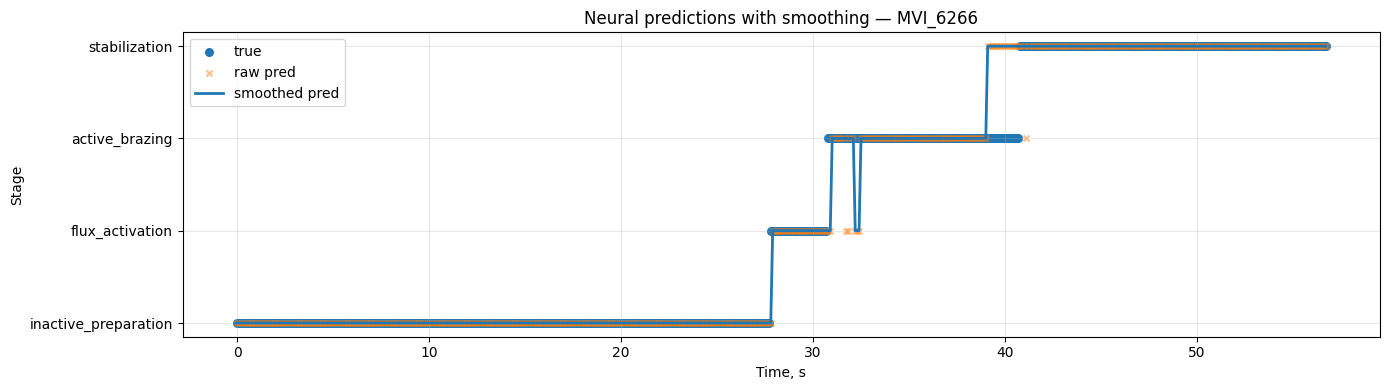

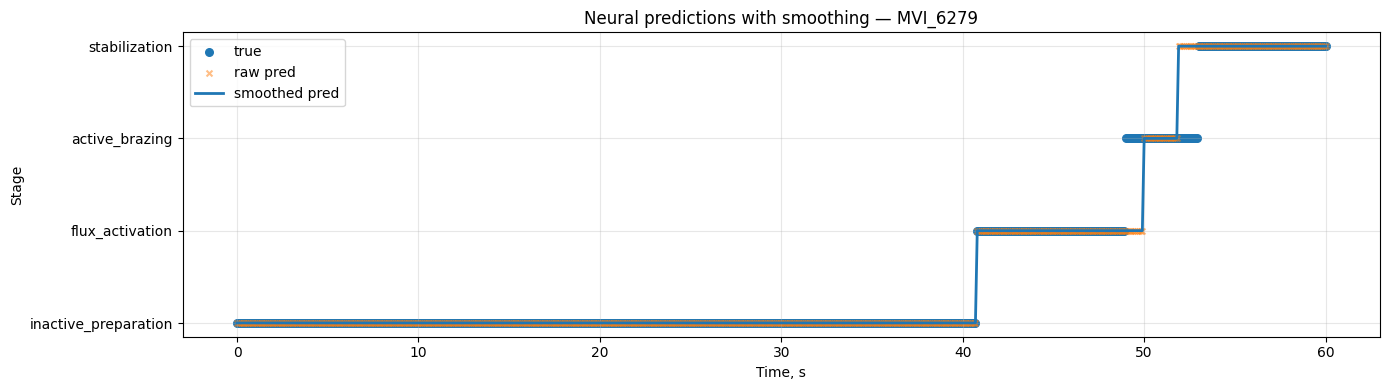

In [58]:
def plot_smoothed_predictions_for_video(video_id: str):
    video_df = test_smoothed_df[
        test_smoothed_df["video_id"] == video_id
    ].sort_values("timestamp_s")

    if len(video_df) == 0:
        print(f"No rows for {video_id}")
        return

    plt.figure(figsize=(14, 4))

    plt.scatter(
        video_df["timestamp_s"],
        video_df["stage_id"],
        s=30,
        label="true",
        marker="o",
    )

    plt.scatter(
        video_df["timestamp_s"],
        video_df["pred_stage_id"],
        s=18,
        label="raw pred",
        marker="x",
        alpha=0.5,
    )

    plt.plot(
        video_df["timestamp_s"],
        video_df["pred_stage_id_smooth"],
        label="smoothed pred",
        linewidth=2,
    )

    plt.yticks([0, 1, 2, 3], STAGE_ORDER)
    plt.xlabel("Time, s")
    plt.ylabel("Stage")
    plt.title(f"Neural predictions with smoothing — {video_id}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_path = FIGURES_DIR / f"{video_id}_smoothed_neural_predictions_timeline_{FPS}.png"
    plt.savefig(output_path, dpi=160)
    plt.show()


for video_id in sorted(test_smoothed_df["video_id"].unique()):
    plot_smoothed_predictions_for_video(video_id)

# results

In [59]:
!mkdir -p "$DRIVE_CHECKPOINTS_DIR"
!cp -r "$CHECKPOINTS_DIR"/. "$DRIVE_CHECKPOINTS_DIR"/


В финальном эксперименте была проверена нейросетевая классификация стадий пайки на датасете, сформированном с частотой 10 FPS. Переход с 3 FPS на 10 FPS был выполнен для увеличения числа кадров в коротких и технологически важных стадиях, прежде всего `active_brazing` и `flux_activation`.

В качестве основных вариантов были проверены:

- `ResNet18` со стандартными class weights;
- `ResNet18` с усиленным весом стадии `active_brazing`;
- `MobileNetV3 Small` со стандартными class weights.

По validation split лучшей моделью стала `ResNet18` со стандартными class weights:

```text
resnet18_base:
best_val_macro_f1 = 0.9199
best_val_accuracy = 0.9533
best_val_active_brazing_f1 = 0.9063
best_val_active_brazing_recall = 0.8406
````

На test split модель `resnet18_base` показала следующие результаты:

```text
accuracy:    0.8747
macro_f1:    0.8209
weighted_f1: 0.8895
```

После temporal smoothing качество немного улучшилось:

```text
accuracy:    0.8776
macro_f1:    0.8290
weighted_f1: 0.8926
```

Главным положительным результатом стало улучшение распознавания стадии `active_brazing`. По сравнению с baseline на 3 FPS полнота и F1-score этой стадии заметно выросли:

```text
3 FPS ResNet18:
active_brazing recall = 0.5000
active_brazing f1     = 0.6667

10 FPS ResNet18 base:
active_brazing recall = 0.6837
active_brazing f1     = 0.8097

10 FPS ResNet18 base + smoothing:
active_brazing recall = 0.7194
active_brazing f1     = 0.8368
```

Это подтверждает, что увеличение частоты кадров улучшает представление коротких и переходных стадий процесса, особенно стадии активной пайки.

Основная оставшаяся проблема связана с ложными срабатываниями класса `flux_activation`. Наиболее частая ошибка:

```text
inactive_preparation → flux_activation: 152
```

Также сохраняются ошибки на границах стадии `active_brazing`:

```text
active_brazing → flux_activation: 32
active_brazing → stabilization: 30
```

Таким образом, финальная нейросетевая модель стала лучше распознавать активную пайку, но часть подготовительных кадров ошибочно относится к активации флюса. Для операторского мониторинга это указывает на необходимость использования технологической логики переходов между стадиями. В дальнейшем поверх нейросетевой модели целесообразно реализовать state machine, которая будет подтверждать переходы между стадиями несколькими устойчивыми предсказаниями и запрещать невозможные скачки состояния.

Итог: модель `ResNet18`, обученная на 10 FPS датасете, является более подходящей основой для финальной системы определения стадий пайки, чем baseline на 3 FPS, поскольку существенно лучше распознаёт стадию `active_brazing`, имеющую ключевое значение для дальнейшей управляющей логики.